In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sn
import statsmodels.api as sm
from scipy.stats import norm
from scipy.stats import binom
from scipy.stats import hypergeom
from scipy.stats import t
from scipy.stats import chi2
from scipy.stats import contingency
import pingouin as pg
#from sklearn import datasets
from sklearn.cluster import KMeans 
from sklearn.preprocessing import StandardScaler 
from sklearn.metrics import silhouette_score, silhouette_samples, r2_score
from sklearn.model_selection import KFold, train_test_split
#from yellowbrick.cluster import SilhouetteVisualizer 
plt.rcParams['font.family'] = 'monospace'
import warnings
warnings.filterwarnings('ignore')

## 1) Beschreibende Statistik - Univariater Fall

In [15]:
ChristmasSales = pd.read_csv("Christmas Sales and Trends.csv", sep=';', decimal=',')
display(ChristmasSales.head(3))
display(ChristmasSales.tail(3))

#a)
ChristmasSales.describe()

,TransactionID,Date,Time,CustomerID,Age,Gender,Location,StoreID,OnlineOrderFlag,ProductID,...,PromotionApplied,DiscountAmount,Total Sales,GiftWrap,ShippingMethod,DeliveryTime,Weather,Event,CustomerSatisfaction,ReturnFlag
0,1,24.12.2020,07:27:59,441,27,Other,City_15,NaN,WAHR,106,...,FALSCH,0.0,483.931273,FALSCH,Standard,5.0,Snowy,NaN,5,FALSCH
1,2,18.11.2022,14:36:39,340,43,Male,City_13,NaN,WAHR,816,...,WAHR,0.0,95.279579,WAHR,Express,3.0,Sunny,NaN,2,WAHR
2,3,26.12.2019,20:23:50,31,25,Other,City_7,92.0,FALSCH,508,...,FALSCH,0.0,104.743291,FALSCH,NaN,NaN,Rainy,Christmas Market,4,FALSCH


,TransactionID,Date,Time,CustomerID,Age,Gender,Location,StoreID,OnlineOrderFlag,ProductID,...,PromotionApplied,DiscountAmount,Total Sales,GiftWrap,ShippingMethod,DeliveryTime,Weather,Event,CustomerSatisfaction,ReturnFlag
9997,9998,02.11.2021,23:20:58,202,46,Female,City_13,22.0,FALSCH,892,...,WAHR,7.368328,66.314952,WAHR,NaN,NaN,Snowy,Black Friday,2,FALSCH
9998,9999,11.11.2020,11:33:17,310,64,Other,City_8,NaN,WAHR,237,...,WAHR,0.000000,61.004291,WAHR,Express,1.0,Sunny,Christmas Market,1,FALSCH
9999,10000,16.11.2022,17:01:01,469,39,Female,City_15,NaN,WAHR,490,...,WAHR,0.000000,328.028730,WAHR,Overnight,2.0,Snowy,Christmas Market,2,WAHR


,TransactionID,CustomerID,Age,StoreID,ProductID,Quantity,UnitPrice,TotalPrice,DiscountAmount,Total Sales,DeliveryTime,CustomerSatisfaction
count,10000.00000,10000.00000,10000.000000,4582.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,5418.000000,10000.000000
mean,5000.50000,251.93300,43.791700,50.920559,500.234800,3.010600,54.962118,165.426015,6.954545,158.471470,3.004245,2.982500
std,2886.89568,145.00392,15.366585,28.864546,288.741317,1.404452,26.239370,116.107776,11.075408,111.732411,1.419484,1.419153
min,1.00000,1.00000,18.000000,1.000000,1.000000,1.000000,10.003242,10.017153,0.000000,9.015438,1.000000,1.000000
25%,2500.75000,127.00000,30.000000,26.000000,252.000000,2.000000,32.053314,71.897205,0.000000,68.543548,2.000000,2.000000
50%,5000.50000,254.00000,44.000000,51.000000,500.000000,3.000000,55.035737,136.291203,0.000000,130.410016,3.000000,3.000000
75%,7500.25000,379.00000,57.000000,76.000000,750.000000,4.000000,77.849652,241.049782,10.407700,229.478096,4.000000,4.000000
max,10000.00000,500.00000,70.000000,100.000000,1000.000000,5.000000,99.996579,499.982894,49.945866,499.982894,5.000000,5.000000


a) Metrische Merkmale diesen Datensatzes sind TransactionID, CustomerID, Age, StoreID, ProductID, Quantity, DeliveryTime, CustomerSatisfaction (diese können mit ChristmasSales.describe() herausgefunden werden)

0    483.931273
1     95.279579
2    104.743291
Name: TotalPrice, dtype: float64

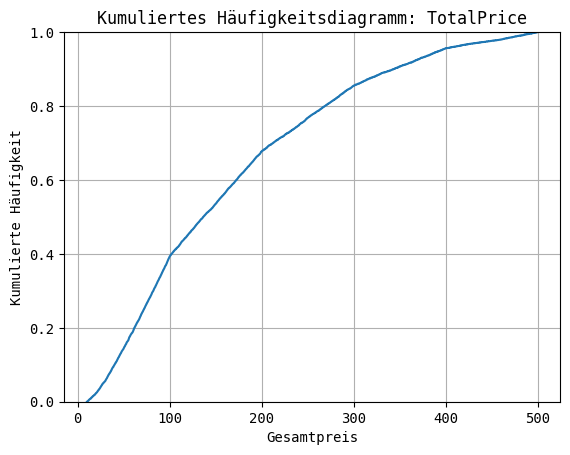

Der Mindestwert der oberen 10% ist: 343.25765905000003


In [ ]:
#b)
ChristmasSalesTotalPrice = ChristmasSales['TotalPrice']
display(ChristmasSalesTotalPrice.head(3))

sn.ecdfplot(data=ChristmasSalesTotalPrice)

plt.title('Kumuliertes Häufigkeitsdiagramm: TotalPrice')
plt.xlabel('Gesamtpreis')
plt.ylabel('Kumulierte Häufigkeit')
plt.grid(True)
plt.show()


print(f"Der Mindestwert der oberen 10% ist: {ChristmasSalesTotalPrice.quantile(0.9)}")

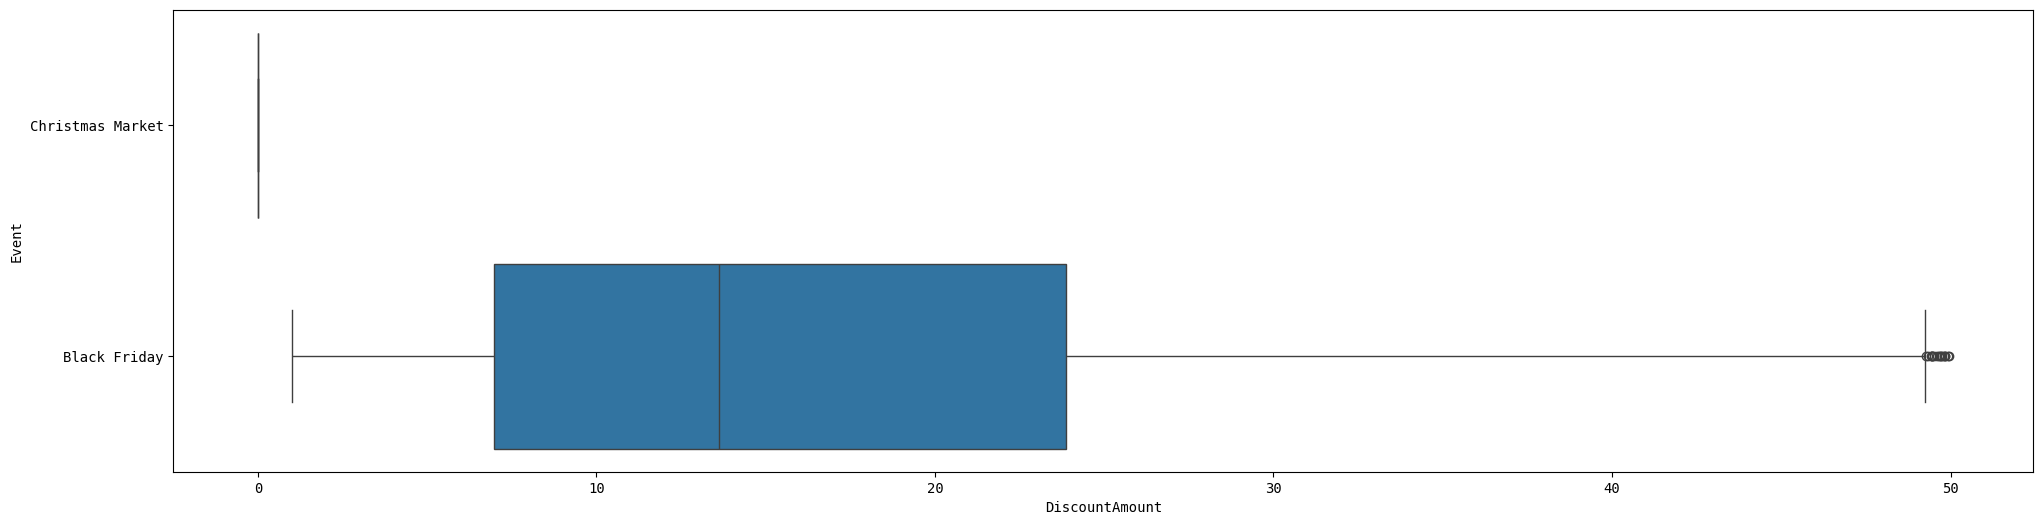

In [25]:
plt.figure(figsize=(24, 6))
sn.boxplot(data=ChristmasSales, x='DiscountAmount', y='Event')
plt.show()

c)
Median: Die vertikale Linie in der Box markiert den Zentralwert der Daten.

Box: Sie repräsentiert die mittleren 50% der Daten (Interquartilsabstand zwischen Q1 und Q3).

Whiskers: Die Linien links und rechts zeigen die Streuung der Daten außerhalb der Box.

Ausreißer: Die Punkte ganz rechts markieren Extremwerte jenseits der Whiskers.

Interpretation der Grafik
Zentrale Tendenz: Das Event Black Friday weist einen deutlich höheren Median-Rabatt auf (ca. 14). Beim Christmas Market liegt dieser bei ca. 0.

Streuung: Die Rabatte am Black Friday variieren stark (breite Box). Am Christmas Market sind sie einheitlich bei fast 0 (sehr schmale Box).

Extremwerte: Nur beim Black Friday existieren Ausreißer mit extrem hohen Rabatten bis zu 50.

Vergleich: Die Rabattpolitik am Black Friday ist wesentlich aggressiver und vielfältiger als die des Christmas Market.


## 2) Beschreibende Statistik - Multivariater Fall

Es wird wiederum der Datensatz Christmas Sales and Trends.csv verwendet.
a) Stelle die Kreuztabelle für die Merkmale GiftWrap und Category, inklusive der
entsprechenden Randhäufigkeiten, dar. [1 Punkt]

b) Bestimme folgende bedingte Häufigkeiten: [3 Punkte]
- Das ein Artikel aus der Kategorie *Food* eingepackt
(GiftWrap = True) wird.
- Das ein unverpackter Artikel aus der Kategorie
*Decorations* stammt.
- Das ein eingepackter Artikel **nicht** zur Kategorie *Toys*
gehört.

c) Bestimme den Korrigierten Kontingenzkoeffizient für die Merkmale Weather
und Category. Welche Aussage lässt sich aus dem Ergebnis ableiten? [2 Punkte]